Running size 3...
Running size 6...
Running size 12...
Running size 24...
Running size 48...
Running size 96...
Running size 192...
Running size 384...


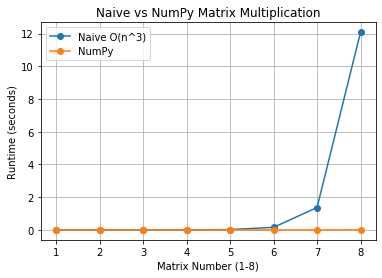

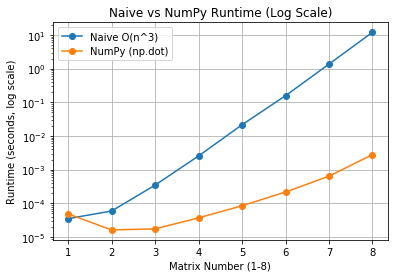

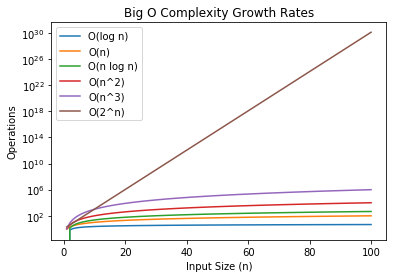

In [13]:
import numpy as np
import time
import matplotlib.pyplot as plt

'''
Implement a large matrix multiplication using both naive (custom function) and optimized
(numpy function) methods and compare their runtimes.

Build 8 pairs of random matrices ( 16 total), the first being 3x3 with the next matrices being 2 x
rows and 2 x columns bigger than the previous matrix (i.e. matrix 1 will be 3x3, matrix 2 will be 6x6,
matrix 3 will be 12x12…)

Time how long it takes to multiply each pair
Compare that time to the numpy version for multiplying each pair.
Compare and plot the runtimes (matrix number vs runtime) for naive and optimized

'''
# Use the custom matrix multiplier from the lecture 
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C


# Matrix sizes
sizes = [3 * (2**i) for i in range(8)]  # [3, 6, 12, 24, 48, 96, 192, 384]

naive_times = [] #custom function
numpy_times = [] #numpy function 


# Run experiment
for size in sizes:
    print(f"Running size {size}...")
    # Generate random matrices
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    # Convert to Python lists for naive function
    A_list = A_np.tolist()
    B_list = B_np.tolist()
    
    # Timing the naive method
    start = time.time()
    naive_matrix_multiplication(A_list, B_list)
    naive_times.append(time.time() - start)
    
    # Timing the numpy method 
    start = time.time()
    np.dot(A_np, B_np)
    numpy_times.append(time.time() - start)


# PLOTTING comparisons
naive_times = np.array(naive_times, dtype=float)
numpy_times = np.array(numpy_times, dtype=float)
sizes_array = np.arange(1, 9)  # Matrix numbers 1-8

# Runtime comparison 
plt.figure()
plt.plot(sizes_array, naive_times, 'o-', label='Naive O(n^3)')
plt.plot(sizes_array, numpy_times, 'o-', label='NumPy')
plt.xlabel("Matrix Number (1-8)")
plt.ylabel("Runtime (seconds)")
plt.title("Naive vs NumPy Matrix Multiplication")
plt.legend()
plt.grid(True)
plt.show()

# Runtime comparison on log scale
plt.figure()
plt.plot(sizes_array, naive_times, 'o-', label='Naive O(n^3)')
plt.plot(sizes_array, numpy_times, 'o-', label='NumPy (np.dot)')
plt.yscale('log')
plt.xlabel("Matrix Number (1-8)")
plt.ylabel("Runtime (seconds, log scale)")
plt.title("Naive vs NumPy Runtime (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()

# Compare with Big-O growth
naive_times = np.array(naive_times, dtype=float)
numpy_times = np.array(numpy_times)

n = np.linspace(1, 100, 100)

plt.plot(n, np.log(n), label='O(log n)') 
plt.plot(n, n, label='O(n)') 
plt.plot(n, n * np.log(n), label='O(n log n)') 
plt.plot(n, n**2, label='O(n^2)') 
plt.plot(n, n**3, label='O(n^3)') 
plt.plot(n, 2**n, label='O(2^n)') 
plt.yscale('log') # Logarithmic scale for better visualization 
plt.title('Big O Complexity Growth Rates') 
plt.xlabel('Input Size (n)') 
plt.ylabel('Operations') 
plt.legend() 
plt.show()